## Assignment 2 - RNN, GRU, & LSTM

Data Preprocessing <br>
- Clean the Text: Remove URLs, special characters, numbers, and extra spaces. Convert
text to lowercase.
- Tokenization: Split the text into individual tokens using a tokenizer suitable for each
model (e.g., Word2Vec for RNN-based models, BERT tokenizer for BERT).
- Class Mapping: Map sentiment labels: <br>
○ 0 → Negative<br>
○ 2 → Neutral<br>
○ 4 → Positive<br> 
- Train-Test Split: Divide the data into training, validation, and test sets.

In [7]:
import nltk
import re
import pandas as pd
import numpy as np
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from gensim.models import Word2Vec
from torch.nn.utils.rnn import pad_sequence
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

Then let's read the dataset and check their shape.

In [9]:
# read the dataset
train_df = pd.read_csv("../Assignment 1/Data/train.csv", encoding="Windows-1252")
train_df.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
train_df = train_df[["text", "polarity"]]

# read the dataset
test_df = pd.read_csv("../Assignment 1/Data/test.csv", encoding="Windows-1252")
test_df.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
test_df = test_df[["text", "polarity"]]

# convert target variables into pytorch tensors
label_map = {"negative": 0, "neutral":1, "positive": 2}

train_df["polarity"] = train_df["polarity"].map(label_map)
test_df["polarity"] = test_df["polarity"].map(label_map)

test_df.head()

,text,polarity
0,Last session of the day http://twitpic.com/67ezh,1.0
1,Shanghai is also really exciting (precisely -...,2.0
2,"Recession hit Veronique Branquinho, she has to...",0.0
3,happy bday!,2.0
4,http://twitpic.com/4w75p - I like it!!,2.0


In [10]:
test_df['polarity'].unique()

array([ 1.,  2.,  0., nan])

In [11]:
before = len(train_df)
train_df.dropna(how="any", inplace=True)
print(f"{before - len(train_df)} NaN rows dropped.")

1 NaN rows dropped.


In [12]:
before = len(test_df)
test_df.dropna(how="any", inplace=True)
print(f"{before - len(test_df)} NaN rows dropped.")
test_df['polarity'] = test_df['polarity'].astype('int') 

1281 NaN rows dropped.


In [13]:
test_df.shape

(3534, 2)

Next, we create a function named preprocess_text just like before and apply it on the dataframes.

In [14]:
def text_preprocess(text):
    # Check if the text is a string
    if not isinstance(text, str):
        raise ValueError("Should be a str")
    
    # Remove urls
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Keep only letters and whitespaces
    pattern = r"[a-zA-Z\s']"
    text = ''.join(re.findall(pattern, text))
    
    # Convert to lowercase
    text = text.lower()
    
    # Tokenize the text
    tokens = nltk.word_tokenize(text)
    
    return tokens

In [15]:
train_df.head()

,text,polarity
0,"I`d have responded, if I were going",1
1,Sooo SAD I will miss you here in San Diego!!!,0
2,my boss is bullying me...,0
3,what interview! leave me alone,0
4,"Sons of ****, why couldn`t they put them on t...",0


In [16]:
#apply the text_preprocess to 
train_df["text_preprocessed"] = train_df["text"].apply(text_preprocess)
test_df["text_preprocessed"] = test_df["text"].apply(text_preprocess)

In [17]:
#check the head of train data
train_df.head()

,text,polarity,text_preprocessed
0,"I`d have responded, if I were going",1,"[id, have, responded, if, i, were, going]"
1,Sooo SAD I will miss you here in San Diego!!!,0,"[sooo, sad, i, will, miss, you, here, in, san,..."
2,my boss is bullying me...,0,"[my, boss, is, bullying, me]"
3,what interview! leave me alone,0,"[what, interview, leave, me, alone]"
4,"Sons of ****, why couldn`t they put them on t...",0,"[sons, of, why, couldnt, they, put, them, on, ..."


In [18]:
train_df["text_preprocessed"].apply(lambda x: len(x)).describe()

count    27480.000000
mean        12.564702
std          6.795787
min          0.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: text_preprocessed, dtype: float64

In [19]:
before = len(train_df)
train_df.drop_duplicates(subset=["text", "polarity"], inplace=True)
print(f"{before - len(train_df)} rows are dropped")
print(f"dataset has {len(train_df)} rows")

0 rows are dropped
dataset has 27480 rows


In [20]:
before = len(test_df)
test_df.drop_duplicates(subset=["text", "polarity"], inplace=True)
print(f"{before - len(test_df)} rows are dropped")
print(f"dataset has {len(test_df)} rows")

0 rows are dropped
dataset has 3534 rows


In [21]:
def is_garbled(text, threshold=0.5):
    non_alpha_ratio = len(re.findall(r'[^a-zA-Z\s]', text)) / max(len(text), 1)
    return non_alpha_ratio > threshold

In [22]:
before = len(train_df)
train_df = train_df[~train_df["text"].apply(is_garbled)]
print(f"{before - len(train_df)} rows are dropped")
print(f"dataset has {len(train_df)} rows")

18 rows are dropped
dataset has 27462 rows


In [23]:
before = len(test_df)
test_df = test_df[~test_df["text"].apply(is_garbled)]
print(f"{before - len(test_df)} rows are dropped")
print(f"dataset has {len(test_df)} rows")

1 rows are dropped
dataset has 3533 rows


As you can see, we have achieved our desired result.

> [!NOTE] Should split before the next step

<Axes: xlabel='text_preprocessed', ylabel='Count'>

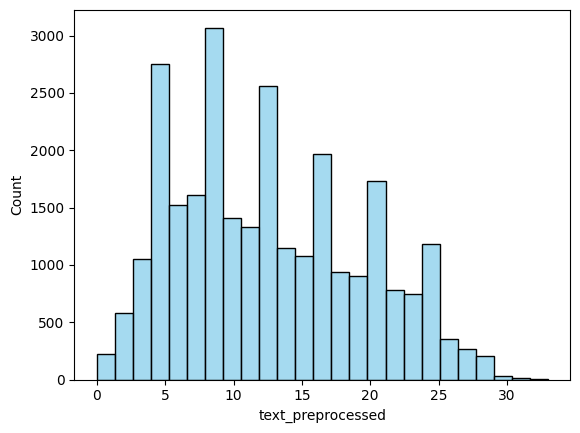

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate word counts
train_word_counts = train_df['text_preprocessed'].apply(lambda x: len(x))

# Create side-by-side histograms with separate y-axis scales
sns.histplot(train_word_counts, bins=25, color='skyblue')

In [27]:
# Fetch embeddings
word2vec_model = Word2Vec(
    sentences=train_df.text_preprocessed.values.tolist(), 
    vector_size=100, min_count=1, workers=4
    )

# Get vocabulary size
vocab_size = len(word2vec_model.wv)
print(vocab_size)

27042


In [30]:
# Convert text to Word2Vec embeddings
def text_to_embeddings(text, word2vec_model, seq_length):
    embeddings = []
    counter = 0
    word_count = len(text)
    for i, word in enumerate(text):
        if word in word2vec_model.wv:
            if i == seq_length:
                break
            embeddings.append(word2vec_model.wv[word])
        else:
            counter += 1
            continue
        
    if word_count !=0 and (counter / word_count) > 0.25:
        print(f"{counter} words were dropped out of {word_count}")
    # Padding the sequences
    if len(embeddings) < seq_length:
        zero_padding = [np.zeros(word2vec_model.vector_size) \
                        for _ in range(seq_length - len(embeddings))]

        embeddings = zero_padding + embeddings

    return embeddings[:seq_length]

In [32]:
# Prepare data
def prepare_data(reviews, labels, word2vec_model):
    X = [text_to_embeddings(review, word2vec_model, 64) for review in reviews]
    X = [torch.tensor(embeddings, dtype=torch.float32) for embeddings in X]
    y = torch.tensor(labels, dtype=torch.long)
    return X, y

In [33]:
# Prepare data
X_train, y_train = prepare_data(train_df.text_preprocessed, train_df.polarity,
                                word2vec_model)

X_val, y_val = prepare_data(test_df.text_preprocessed, test_df.polarity,
                            word2vec_model)

C:\Users\raad\AppData\Local\Temp\ipykernel_28768\3888103417.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  X = [torch.tensor(embeddings, dtype=torch.float32) for embeddings in X]


2 words were dropped out of 7
1 words were dropped out of 2
1 words were dropped out of 2
4 words were dropped out of 11
1 words were dropped out of 3
2 words were dropped out of 3
3 words were dropped out of 4
2 words were dropped out of 4
2 words were dropped out of 5
3 words were dropped out of 7
1 words were dropped out of 3
1 words were dropped out of 1
1 words were dropped out of 3
1 words were dropped out of 2
1 words were dropped out of 1
2 words were dropped out of 5
3 words were dropped out of 7
1 words were dropped out of 3
4 words were dropped out of 7
2 words were dropped out of 7
3 words were dropped out of 11
1 words were dropped out of 2
2 words were dropped out of 7
6 words were dropped out of 21
1 words were dropped out of 3
5 words were dropped out of 18
2 words were dropped out of 6
2 words were dropped out of 5
1 words were dropped out of 2
1 words were dropped out of 2
1 words were dropped out of 3
2 words were dropped out of 4
4 words were dropped out of 6
2 word

## BiRNN

In [37]:
# Define hyperparameters
input_size = word2vec_model.vector_size
hidden_size = 128
output_size = 3
num_layers = 1
learning_rate = 0.001
num_epochs = 30
batch_size = 64
dropout_rate = 0.5
leaky_relu_slope = 0.1

In [39]:
# Create DataLoader
train_data = TensorDataset(torch.stack(X_train), y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [40]:
# Create DataLoader
val_data = TensorDataset(torch.stack(X_val), y_val)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)

In [41]:
def calculate_accuracy(loader, model, device=None):
    """
    Computes overall accuracy for a 3-class classification model.
    Expects model to return logits of shape (batch, 3) and labels to be dtype torch.long with values 0,1,2.
    Returns accuracy as percentage.
    """
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()
            outputs = model(inputs)                 # logits shape (batch, 3)
            preds = outputs.argmax(dim=1)           # predicted class indices (batch,)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total if total > 0 else 0.0

In [50]:
class SentimentBiRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_rate=0.5):
        super(SentimentBiRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Using RNN for the recurrent layer
        self.bi_rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True,
                             bidirectional=True, dropout=dropout_rate if num_layers > 1 else 0)

        # Doubling the output size because of bidirectionality
        self.fc = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        # Initialize hidden state for RNN
        h0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # Forward propagate the RNN
        out, _ = self.bi_rnn(x, h0)

        # Get the last time step's output for the fully connected layer
        out = self.fc(out[:, -1, :])
        return out

In [47]:
# Initialize model, loss function, and optimizer
model = SentimentBiRNN(input_size, hidden_size, output_size, num_layers, dropout_rate)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Epoch 1/30, Loss: 1.0201, Val Loss: 1.0280
Epoch 2/30, Loss: 0.9977, Val Loss: 1.0929
Epoch 3/30, Loss: 1.0153, Val Loss: 0.9938
Epoch 4/30, Loss: 1.0288, Val Loss: 1.0362
Epoch 5/30, Loss: 1.0060, Val Loss: 0.9760
Epoch 6/30, Loss: 0.9756, Val Loss: 0.9653
Epoch 7/30, Loss: 0.9514, Val Loss: 0.9387
Epoch 8/30, Loss: 0.9822, Val Loss: 0.9679
Epoch 9/30, Loss: 0.9539, Val Loss: 0.9826
Epoch 10/30, Loss: 0.9385, Val Loss: 0.9418
Early stopped at 10
Lowest Validation Loss: 0.9387 at Epoch 7


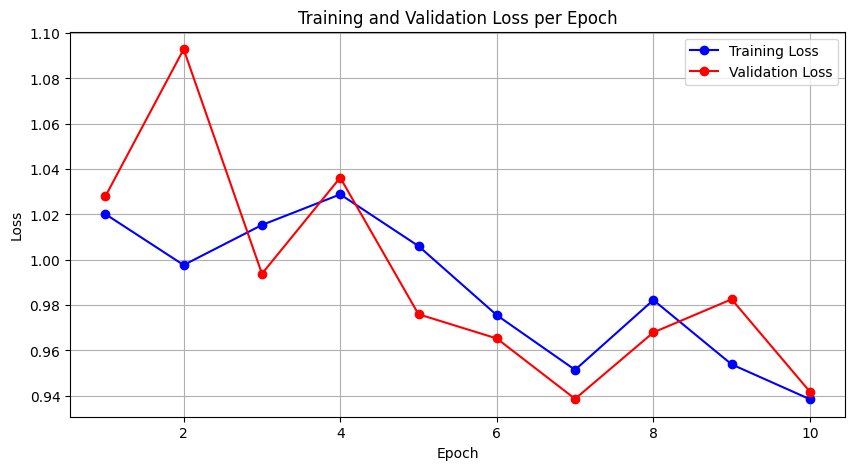

In [48]:
#Training loop
import matplotlib.pyplot as plt

num_epochs = 30  # Number of epochs
losses = []  # List to store the average train loss per epoch
val_losses = []  # List to store the average validation loss per epoch
best_val_loss = float('inf')  # Initialize the best validation loss to infinity
best_epoch = 0  # Epoch with the best validation loss
patience = 0
max_patience = 3  # Maximum epochs to wait for improvement

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0
    total_val_loss = 0
    count = 0
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count
    losses.append(average_loss)

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            val_outputs = val_outputs.squeeze()
            val_loss = criterion(val_outputs, labels.long())
            total_val_loss += val_loss.item()
            val_count += 1
    average_val_loss = total_val_loss / val_count
    val_losses.append(average_val_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')
    
    # Check if the current validation loss is the lowest; if so, save the model
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'bidirectional_best_model.pth')  # Save the best model
        patience = 0   
    else:
        patience += 1

    if patience >= max_patience:
        print(f'Early stopped at {epoch+1}')
        break  # Stop training

print(f'Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch + 1}')

# Plotting the training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(range(1, (len(losses)+1)), losses, 'bo-', label='Training Loss')
plt.plot(range(1, (len(losses)+1)), val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [49]:
# Load the best model and calculate accuracy only for that
model.load_state_dict(torch.load('bidirectional_best_model.pth'))
train_accuracy = calculate_accuracy(train_loader, model)
val_accuracy = calculate_accuracy(val_loader, model)
print(f'Best Model Training Accuracy: {train_accuracy}%')
print(f'Best Model Validation Accuracy: {val_accuracy}%')

Best Model Training Accuracy: 55.72427354162115%
Best Model Validation Accuracy: 55.10897254457968%


## Using Bi-Directional GRU Model

In [58]:
class SentimentGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_rate=0.5, leaky_relu_slope=0.1):
        super(SentimentGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, 
                          bidirectional=True, dropout=dropout_rate if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size * 2, output_size)  # Output size is doubled because of bidirectionality
    
    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # Forward propagate the GRU
        out, _ = self.gru(x, h0)
        # Apply Leaky ReLU activation
        # out = nn.functional.leaky_relu(out)
        # Apply dropout
        out = self.dropout(out)
        # Use only the last output for the fully connected layer
        out = self.fc(out[:, -1, :])
        # Apply sigmoid to the output layer
        return out

In [59]:
# Initialize model, loss function, and optimizer
model = SentimentGRU(input_size, hidden_size, output_size, num_layers, dropout_rate, leaky_relu_slope)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Epoch 1/30, Loss: 0.9671, Val Loss: 0.8933
Epoch 2/30, Loss: 0.8851, Val Loss: 0.8485
Epoch 3/30, Loss: 0.8516, Val Loss: 0.8274
Epoch 4/30, Loss: 0.8322, Val Loss: 0.8007
Epoch 5/30, Loss: 0.8209, Val Loss: 0.7943
Epoch 6/30, Loss: 0.8063, Val Loss: 0.7877
Epoch 7/30, Loss: 0.7939, Val Loss: 0.7909
Epoch 8/30, Loss: 0.7801, Val Loss: 0.7825
Epoch 9/30, Loss: 0.7699, Val Loss: 0.7886
Epoch 10/30, Loss: 0.7591, Val Loss: 0.7610
Epoch 11/30, Loss: 0.7491, Val Loss: 0.7652
Epoch 12/30, Loss: 0.7372, Val Loss: 0.7657
Epoch 13/30, Loss: 0.7230, Val Loss: 0.7576
Epoch 14/30, Loss: 0.7128, Val Loss: 0.7681
Epoch 15/30, Loss: 0.6957, Val Loss: 0.7869
Epoch 16/30, Loss: 0.6858, Val Loss: 0.7839
Early stopped at 16
Lowest Validation Loss: 0.7576 at Epoch 13


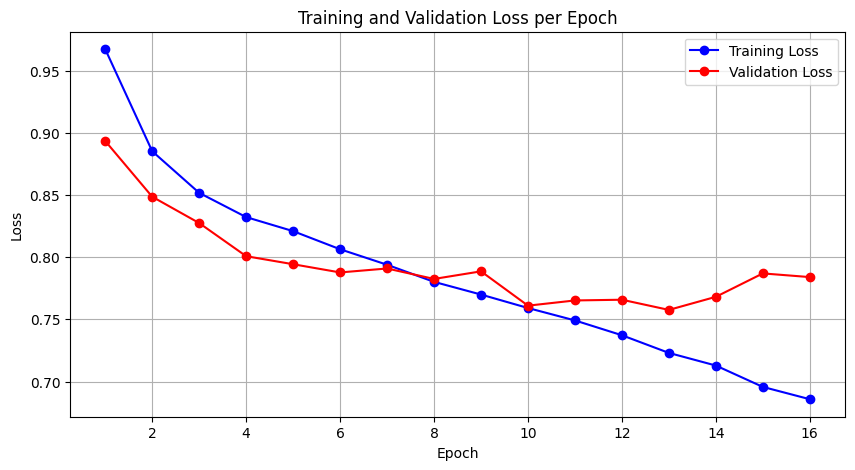

In [60]:
#Training loop
import matplotlib.pyplot as plt

num_epochs = 30  # Number of epochs
losses = []  # List to store the average train loss per epoch
val_losses = []  # List to store the average validation loss per epoch
best_val_loss = float('inf')  # Initialize the best validation loss to infinity
best_epoch = 0  # Epoch with the best validation loss
patience = 0
max_patience = 3  # Maximum epochs to wait for improvement

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0
    total_val_loss = 0
    count = 0
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count
    losses.append(average_loss)

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            val_outputs = val_outputs.squeeze()
            val_loss = criterion(val_outputs, labels.long())
            total_val_loss += val_loss.item()
            val_count += 1
    average_val_loss = total_val_loss / val_count
    val_losses.append(average_val_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')
    
    # Check if the current validation loss is the lowest; if so, save the model
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'bi_gru_best_model.pth')  # Save the best model
        patience = 0   
    else:
        patience += 1

    if patience >= max_patience:
        print(f'Early stopped at {epoch+1}')
        break  # Stop training

print(f'Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch + 1}')

# Plotting the training and validation losses

plt.figure(figsize=(10, 5))
plt.plot(range(1, (len(losses)+1)), losses, 'bo-', label='Training Loss')
plt.plot(range(1, (len(losses)+1)), val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [61]:
# Load the best model and calculate accuracy only for that
model.load_state_dict(torch.load('bi_gru_best_model.pth'))
train_accuracy = calculate_accuracy(train_loader, model)
val_accuracy = calculate_accuracy(val_loader, model)
print(f'Best Model Training Accuracy: {train_accuracy}%')
print(f'Best Model Validation Accuracy: {val_accuracy}%')

Best Model Training Accuracy: 70.99628577670964%
Best Model Validation Accuracy: 66.79875459949052%


# Video 12 - Bidirectional LSTM Model

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_rate=0.5, leaky_relu_slope=0.1):
        super(SentimentLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.leaky_relu_slope = leaky_relu_slope

        # # Create LSTM layers with nn.LSTM

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        
        # Define dropout layer
        self.dropout = nn.Dropout(dropout_rate)

        # Fully connected layer (output size is doubled for bidirectionality)
        self.fc = nn.Linear(hidden_size * 2, output_size)


    def forward(self, x):
        h_0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c_0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)

        outputs, _ = self.lstm(x, (h_0, c_0))
        
        # Apply dropout and fully connected layer
        outputs = self.dropout(outputs)
        
        out = self.fc(outputs[:, -1, :])

        return out


In [74]:
# Initialize model, loss function, and optimizer
model = SentimentLSTM(input_size, hidden_size, output_size, num_layers, dropout_rate, leaky_relu_slope)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [75]:
#Training loop
import matplotlib.pyplot as plt

num_epochs = 30  # Number of epochs
losses = []  # List to store the average train loss per epoch
val_losses = []  # List to store the average validation loss per epoch
best_val_loss = float('inf')  # Initialize the best validation loss to infinity
best_epoch = 0  # Epoch with the best validation loss
patience = 0
max_patience = 5  # Maximum epochs to wait for improvement

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0
    total_val_loss = 0
    count = 0
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count
    losses.append(average_loss)

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            val_outputs = val_outputs.squeeze()
            val_loss = criterion(val_outputs, labels.long())
            total_val_loss += val_loss.item()
            val_count += 1
    average_val_loss = total_val_loss / val_count
    val_losses.append(average_val_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')
    
    # Check if the current validation loss is the lowest; if so, save the model
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'bi_lstm_best_model.pth')  # Save the best model
        patience = 0   
    else:
        patience += 1

    if patience >= max_patience:
        print(f'Early stopped at {epoch+1}')
        break  # Stop training

print(f'Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch + 1}')

# Plotting the training and validation losses

plt.figure(figsize=(10, 5))
plt.plot(range(1, (len(losses)+1)), losses, 'bo-', label='Training Loss')
plt.plot(range(1, (len(losses)+1)), val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

Epoch 1/30, Loss: 0.9882, Val Loss: 0.9230
Epoch 2/30, Loss: 0.9088, Val Loss: 0.8744
Epoch 3/30, Loss: 0.8736, Val Loss: 0.8571
Epoch 4/30, Loss: 0.8495, Val Loss: 0.8291
Epoch 5/30, Loss: 0.8334, Val Loss: 0.8075
Epoch 6/30, Loss: 0.8195, Val Loss: 0.8134
Epoch 7/30, Loss: 0.8050, Val Loss: 0.7807
Epoch 8/30, Loss: 0.7911, Val Loss: 0.7942
Epoch 9/30, Loss: 0.7817, Val Loss: 0.7915
Epoch 10/30, Loss: 0.7732, Val Loss: 0.7661
Epoch 11/30, Loss: 0.7631, Val Loss: 0.7669
Epoch 12/30, Loss: 0.7561, Val Loss: 0.7727
Epoch 13/30, Loss: 0.7435, Val Loss: 0.7678
Epoch 14/30, Loss: 0.7313, Val Loss: 0.7608
Epoch 15/30, Loss: 0.7224, Val Loss: 0.7621


KeyboardInterrupt: 

In [76]:
# Load the best model and calculate accuracy only for that
model.load_state_dict(torch.load('bi_lstm_best_model.pth'))
train_accuracy = calculate_accuracy(train_loader, model)
val_accuracy = calculate_accuracy(val_loader, model)
print(f'Best Model Training Accuracy: {train_accuracy}%')
print(f'Best Model Validation Accuracy: {val_accuracy}%')

Best Model Training Accuracy: 69.56521739130434%
Best Model Validation Accuracy: 66.6855363713558%


## Comparative Study

Put a table / do confusion matrix

| Model | Val Loss | Val Acc | ROC AUC |
| - | - | - | - |
| RNN  | 0.  | 0.  | Use OvR (One versus Rest)  |